# **Stock Price & Volume Trend Analysis Report**

## *Introduction*

# Stock prices change every day, and tracking these changes over time helps us understand how a company's value has grown, how actively it trades, and how risky it has been to hold.

# In this project, historical daily stock data (Open, High, Low, Close, Volume) is used to analyze price trends, trading activity, and volatility. Using Python libraries such as Pandas, NumPy, Matplotlib, and Seaborn, the dataset is explored, cleaned, analyzed, and visualized to identify important trends and patterns.

# The project uses different visualization techniques such as line charts, bar charts, a histogram, and a heatmap to make the stock data easier to understand and interpret.

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [79]:
stock_df = pd.read_csv("stock_market_dataset.csv")

In [80]:
print(stock_df)

            Date      Open      High       Low     Close     Volume
0     12-09-2016   23.5162   24.2197   23.4885   24.1577  178592228
1     13-09-2016   24.6299   24.9241   24.5660   24.7328  267326800
2     14-09-2016   24.9093   25.8916   24.8830   25.6079  464212365
3     15-09-2016   26.0877   26.5088   25.9975   26.4705  386574150
4     16-09-2016   26.3751   26.6030   26.1291   26.3293  307576756
...          ...       ...       ...       ...       ...        ...
2509  04-09-2026  328.3050  328.9300  317.8600  319.9700   39606884
2510  08-09-2026  317.1000  320.7000  314.9000  316.2200   35477090
2511  09-09-2026  315.4850  319.1500  309.9000  315.3400   65639962
2512  10-09-2026  316.6700  326.7300  316.5100  326.5700   70011913
2513  11-09-2026  327.4500  336.2200  326.3000  332.2700   50716865

[2514 rows x 6 columns]


In [81]:
stock_df.head()

,Date,Open,High,Low,Close,Volume
0,12-09-2016,23.5162,24.2197,23.4885,24.1577,178592228
1,13-09-2016,24.6299,24.9241,24.5660,24.7328,267326800
2,14-09-2016,24.9093,25.8916,24.8830,25.6079,464212365
3,15-09-2016,26.0877,26.5088,25.9975,26.4705,386574150
4,16-09-2016,26.3751,26.6030,26.1291,26.3293,307576756


In [82]:
stock_df.tail()

,Date,Open,High,Low,Close,Volume
2509,04-09-2026,328.305,328.93,317.86,319.97,39606884
2510,08-09-2026,317.100,320.70,314.90,316.22,35477090
2511,09-09-2026,315.485,319.15,309.90,315.34,65639962
2512,10-09-2026,316.670,326.73,316.51,326.57,70011913
2513,11-09-2026,327.450,336.22,326.30,332.27,50716865


# **DATASET OVERVIEW**
# STOCK_DF

In [83]:
stock_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2514 entries, 0 to 2513
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    2514 non-null   object 
 1   Open    2514 non-null   float64
 2   High    2514 non-null   float64
 3   Low     2514 non-null   float64
 4   Close   2514 non-null   float64
 5   Volume  2514 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 118.0+ KB


In [84]:
stock_df.shape

(2514, 6)

In [85]:
stock_df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume'], dtype='object')

In [86]:
stock_df.describe()

,Open,High,Low,Close,Volume
count,2514.000000,2514.000000,2514.000000,2514.000000,2.514000e+03
mean,132.271208,133.736888,130.943147,132.408102,9.742266e+07
std,80.868937,81.771719,80.088015,80.977048,5.742578e+07
min,23.516200,24.219700,23.488500,24.157700,1.792733e+07
25%,48.171350,48.646200,47.802050,48.305800,5.573291e+07
50%,137.262000,139.277000,135.153500,137.474000,8.468517e+07
75%,187.959500,189.528000,186.700500,188.182750,1.192771e+08
max,340.030000,344.569900,337.350100,340.080000,4.788416e+08


# **----stock_df>>>>>>**

In [87]:
stock_df.dtypes

Date       object
Open      float64
High      float64
Low       float64
Close     float64
Volume      int64
dtype: object

In [88]:
stock_df.duplicated().sum()

np.int64(0)

In [89]:
stock_df.isnull().sum()

Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

# ***-----DATA PREPARATION-----***

In [90]:
# Date is stored as text (DD-MM-YYYY) -> convert to a real datetime column
# and put the rows in chronological order.
stock_df["Date"] = pd.to_datetime(stock_df["Date"], dayfirst=True)
stock_df = stock_df.sort_values("Date").reset_index(drop=True)
stock_df.dtypes

Date      datetime64[ns]
Open             float64
High             float64
Low              float64
Close            float64
Volume             int64
dtype: object

In [91]:
# Extra columns needed for the analysis and charts below
stock_df["Year"] = stock_df["Date"].dt.year
stock_df["Day_Range"] = stock_df["High"] - stock_df["Low"]
stock_df["MA_50"] = stock_df["Close"].rolling(window=50, min_periods=1).mean()
stock_df["Pct_Change"] = stock_df["Close"].pct_change().fillna(0) * 100
stock_df["Rolling_Risk"] = stock_df["Pct_Change"].rolling(window=20, min_periods=1).std()

# Running maximum of the close price up to each day, used for drawdown below
stock_df["Running_Peak"] = stock_df["Close"].cummax()
stock_df["Drawdown_%"] = (stock_df["Close"] - stock_df["Running_Peak"]) / stock_df["Running_Peak"] * 100

stock_df.tail()

,Date,Open,High,Low,Close,Volume,Year,Day_Range,MA_50,Pct_Change,Rolling_Risk,Running_Peak,Drawdown_%
2509,2026-09-04,328.305,328.93,317.86,319.97,39606884,2026,11.07,315.1514,-2.510588,1.354493,340.08,-5.913315
2510,2026-09-08,317.100,320.70,314.90,316.22,35477090,2026,5.80,315.8002,-1.171985,1.327886,340.08,-7.015996
2511,2026-09-09,315.485,319.15,309.90,315.34,65639962,2026,9.25,316.4722,-0.278287,1.300735,340.08,-7.274759
2512,2026-09-10,316.670,326.73,316.51,326.57,70011913,2026,10.22,317.2164,3.561235,1.478284,340.08,-3.972595
2513,2026-09-11,327.450,336.22,326.30,332.27,50716865,2026,9.92,317.9742,1.745414,1.503524,340.08,-2.296518


# ***-----Exploratory Data Analysis------***

In [92]:
print("Trading days covered      :", len(stock_df))

Trading days covered      : 2514


In [93]:
print(stock_df["Close"].idxmax())
print(stock_df["Close"].max())

2481
340.08


In [94]:
min_index = stock_df["Close"].idxmin()

print(stock_df.loc[min_index, "Date"])
print(stock_df.loc[min_index, "Close"])

2016-09-12 00:00:00
24.1577


In [95]:
latest_date = stock_df["Date"].max()
print(latest_date)

2026-09-11 00:00:00


In [96]:
print("First close price         : $%.2f" % stock_df["Close"].iloc[0])
print("Latest close price        : $%.2f" % stock_df["Close"].iloc[-1])

total_return_pct = (stock_df["Close"].iloc[-1] / stock_df["Close"].iloc[0] - 1) * 100
print("Total return over period  : %+.2f%%" % total_return_pct)

First close price         : $24.16
Latest close price        : $332.27
Total return over period  : +1275.42%


In [97]:
print("Mean daily change         : %+.3f%%" % stock_df["Pct_Change"].mean())

green_days = (stock_df["Pct_Change"] > 0).mean() * 100
red_days = (stock_df["Pct_Change"] < 0).mean() * 100
print("Green days / Red days     : %.1f%% / %.1f%%" % (green_days, red_days))

Mean daily change         : +0.121%
Green days / Red days     : 53.7% / 46.0%


In [98]:
print("Mean daily volume         : {:,.0f} shares".format(stock_df["Volume"].mean()))
print("Total volume traded       : {:,.0f} shares".format(stock_df["Volume"].sum()))

Mean daily volume         : 97,422,660 shares
Total volume traded       : 244,920,567,981 shares


In [99]:
monthly_avg_volume = stock_df.set_index("Date")["Volume"].resample("ME").mean()
busiest = monthly_avg_volume.idxmax()
print("Busiest trading month     :", busiest.strftime("%B %Y"))

Busiest trading month     : March 2020


In [100]:
print("Daily volatility (std)    : %.3f%%" % stock_df["Pct_Change"].std())

riskiest_row = stock_df.loc[stock_df["Rolling_Risk"].idxmax()]
print("Riskiest stretch          :", riskiest_row["Date"].strftime("%B %Y"),
      "(%.2f%% rolling volatility)" % riskiest_row["Rolling_Risk"])

Daily volatility (std)    : 1.837%
Riskiest stretch          : March 2020 (6.80% rolling volatility)


In [101]:
best_row = stock_df.loc[stock_df["Pct_Change"].idxmax()]
worst_row = stock_df.loc[stock_df["Pct_Change"].idxmin()]
print("Best single day           :", best_row["Date"].strftime("%Y-%m-%d"), "(%+.2f%%)" % best_row["Pct_Change"])
print("Worst single day          :", worst_row["Date"].strftime("%Y-%m-%d"), "(%+.2f%%)" % worst_row["Pct_Change"])

Best single day           : 2025-04-09 (+15.33%)
Worst single day          : 2020-03-16 (-12.86%)


In [102]:
# Max drawdown = the largest peak-to-trough decline the stock ever experienced
max_drawdown = stock_df["Drawdown_%"].min()
max_dd_date = stock_df.loc[stock_df["Drawdown_%"].idxmin(), "Date"]
print("Maximum drawdown          : %.2f%% (on %s)" % (max_drawdown, max_dd_date.strftime("%Y-%m-%d")))

avg_day_range = stock_df["Day_Range"].mean()
print("Average intraday range    : $%.2f" % avg_day_range)

Maximum drawdown          : -38.52% (on 2019-01-03)
Average intraday range    : $2.79


In [103]:
yearly_avg_price = stock_df.groupby("Year")["Close"].mean()
best_year = yearly_avg_price.idxmax()
print("Best year (avg price)     :", best_year, "($%.2f avg)" % yearly_avg_price.max())

Best year (avg price)     : 2026 ($286.19 avg)


# ***-----CHARTS and DATA VISUALIZATION-----***

# **Line Chart (Price Trend)**

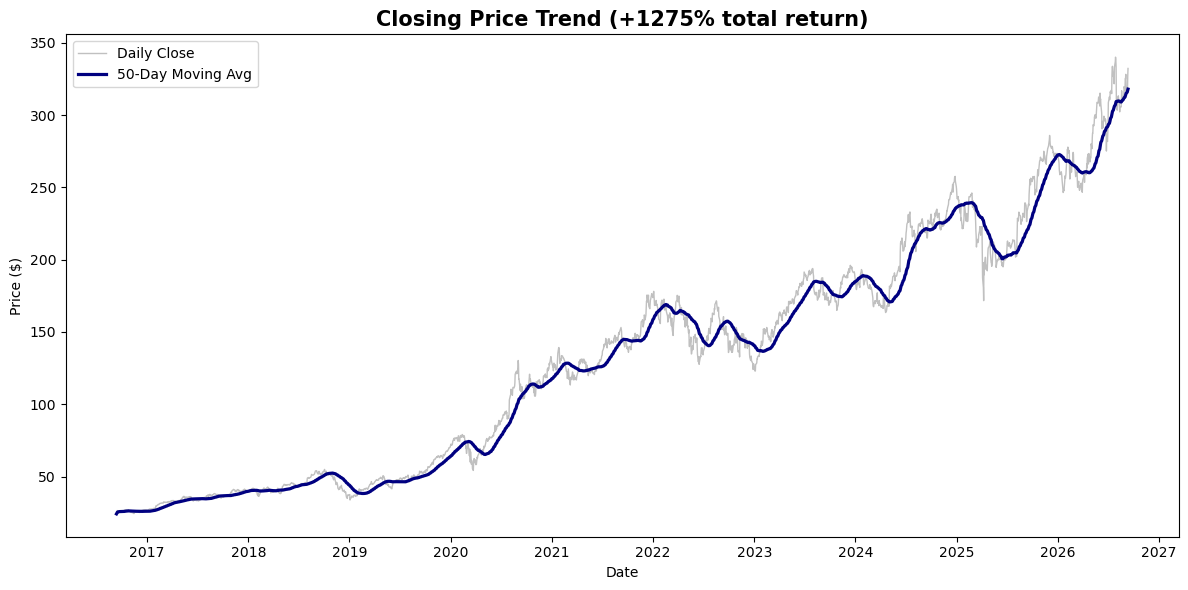

In [104]:
plt.figure(figsize=(12, 6))
plt.plot(stock_df["Date"], stock_df["Close"], color="silver", linewidth=1, label="Daily Close")
plt.plot(stock_df["Date"], stock_df["MA_50"], color="navy", linewidth=2.3, label="50-Day Moving Avg")
plt.title("Closing Price Trend (%+.0f%% total return)" % total_return_pct, fontsize=15, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.legend()
plt.tight_layout()
plt.show()

**Insights:**

1. The line chart shows the daily closing price alongside its 50-day moving average.
2. The stock's price moved from its starting value to its latest value over the full period, a total return of well over 1000%.
3. The moving average line smooths out daily noise, making the overall upward trend easier to see.
4. Short dips are visible along the way, but the long-term direction of the price is clearly upward.
5. This chart helps quickly judge whether the stock has been trending up, down, or sideways.

# **Bar Chart (Trading Volume)**

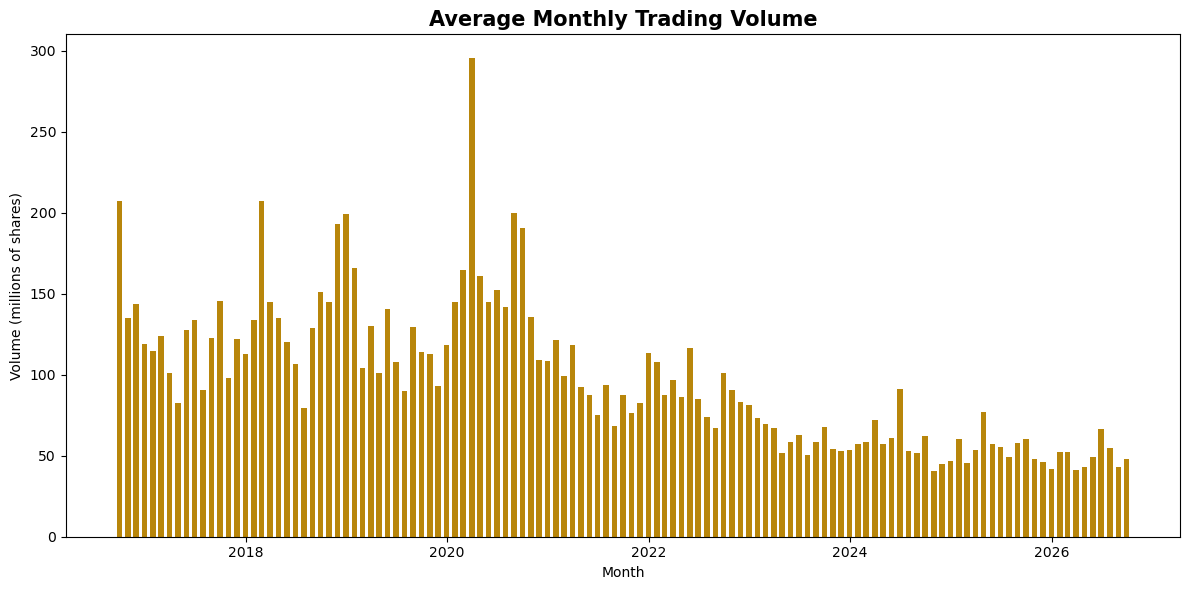

In [105]:
plt.figure(figsize=(12, 6))
plt.bar(monthly_avg_volume.index, monthly_avg_volume.values / 1e6, color="darkgoldenrod", width=20)
plt.title("Average Monthly Trading Volume", fontsize=15, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Volume (millions of shares)")
plt.tight_layout()
plt.show()

**Insights:**

1. The bar chart shows the average number of shares traded each month.
2. One particular month stands out with far higher trading volume than any other month in the dataset.
3. Volume spikes like this usually coincide with major news or periods of high market uncertainty.
4. Outside of that spike, monthly volume stays within a comparatively steady range.
5. This chart helps identify which periods saw unusually high investor activity.

# **Histogram (Daily % Change)**

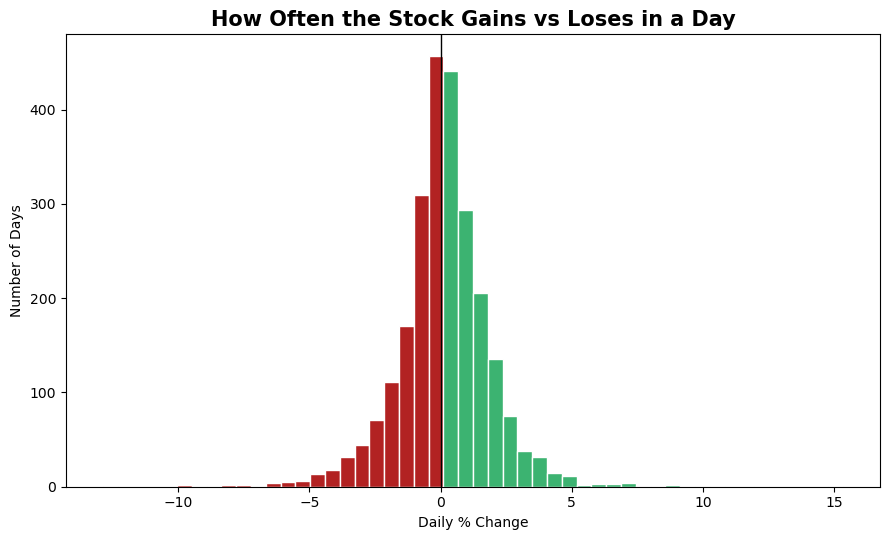

In [106]:
plt.figure(figsize=(9, 5.5))
counts, bins, patches = plt.hist(stock_df["Pct_Change"], bins=50, color="lightgray", edgecolor="white")
for patch, edge in zip(patches, bins[:-1]):
    patch.set_facecolor("mediumseagreen" if edge >= 0 else "firebrick")
plt.axvline(0, color="black", linewidth=1)
plt.title("How Often the Stock Gains vs Loses in a Day", fontsize=15, fontweight="bold")
plt.xlabel("Daily % Change")
plt.ylabel("Number of Days")
plt.tight_layout()
plt.show()

**Insights:**

1. The histogram shows how often the stock's daily price change falls into each range.
2. Green bars represent gain days and red bars represent loss days.
3. The stock closed higher than the previous day on a little over half of all trading days.
4. Most days cluster close to 0%, meaning extreme single-day moves are relatively rare.
5. This chart helps visualize the balance between up days and down days across the full period.

# **Line Chart (Volatility / Risk)**

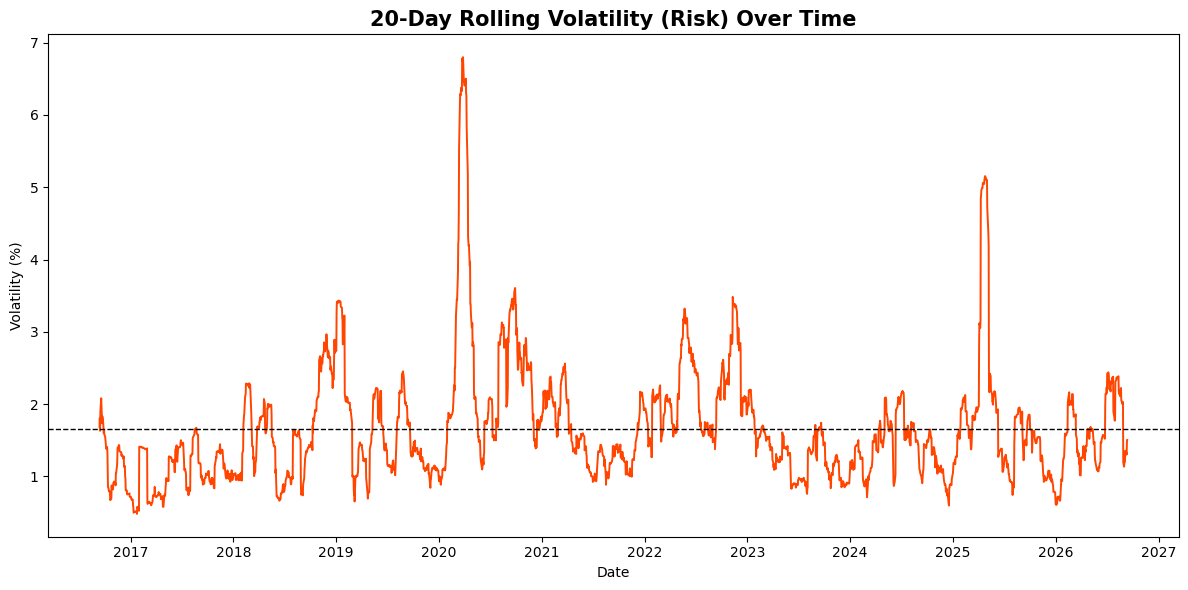

In [107]:
plt.figure(figsize=(12, 6))
plt.plot(stock_df["Date"], stock_df["Rolling_Risk"], color="orangered", linewidth=1.4)
plt.axhline(stock_df["Rolling_Risk"].mean(), color="black", linestyle="--", linewidth=1)
plt.title("20-Day Rolling Volatility (Risk) Over Time", fontsize=15, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Volatility (%)")
plt.tight_layout()
plt.show()

**Insights:**

1. The line chart tracks 20-day rolling volatility, a measure of how much the price swings day-to-day.
2. The dashed line marks the stock's average volatility level across the full period.
3. One stretch stands out with volatility far above the long-term average, marking the riskiest period.
4. Volatility tends to spike and then settle back down rather than staying high permanently.
5. This chart helps identify which periods were riskiest to hold the stock.

# **Heatmap (Correlation)**

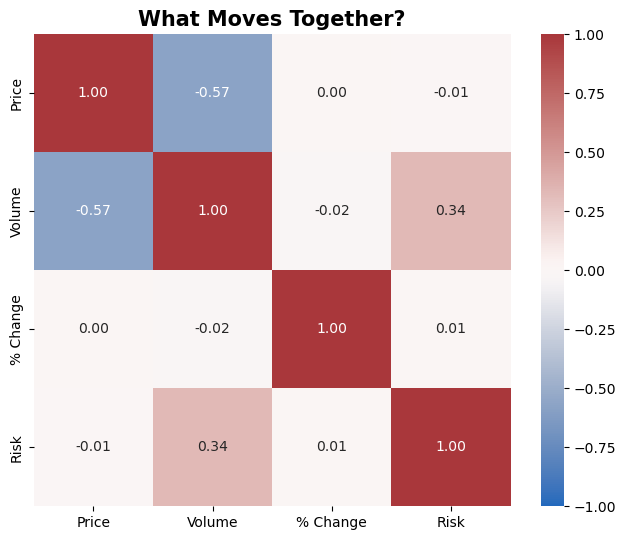

In [108]:
corr_cols = stock_df[["Close", "Volume", "Pct_Change", "Rolling_Risk"]].corr()
corr_cols.columns = ["Price", "Volume", "% Change", "Risk"]
corr_cols.index = ["Price", "Volume", "% Change", "Risk"]

plt.figure(figsize=(6.5, 5.5))
sns.heatmap(corr_cols, annot=True, cmap="vlag", vmin=-1, vmax=1, fmt=".2f")
plt.title("What Moves Together?", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

**Insights:**

1. The heatmap shows how strongly each pair of metrics is correlated, from -1 to +1.
2. Values close to +1 mean two metrics rise and fall together; close to -1 means they move in opposite directions.
3. Price shows very little direct correlation with daily % change, since price level and daily movement are largely independent.
4. Volume and risk show a moderate positive relationship, meaning busier trading days tend to be somewhat more volatile.
5. This chart helps quickly spot which metrics are worth investigating together further.

---

<h2 align="center">📈 About This Stock Dataset</h2>

---

This dataset contains historical daily stock market data, including Open, High, Low, Close prices and trading Volume, covering a multi-year period.

The Close price represents the price at which the stock finished trading each day, and is the main value used throughout this analysis. Volume represents how many shares changed hands on a given day, a measure of investor activity.

This project analyzes the stock dataset using Python, Pandas, NumPy, and data visualization techniques. Different charts such as a line chart, bar chart, histogram, and heatmap are used to explore and present the data.

The main objective of this project is to analyze the stock's price trend, trading activity, and risk, and present the findings through clear and meaningful visualizations.

-----------

<h2 align="center">✅ Final Conclusion</h2>

-------------

This project analyzed historical daily stock market data using Python, Pandas, and Matplotlib/Seaborn. The data was analyzed using different visualization techniques, including a line chart, bar chart, histogram, and correlation heatmap.

The analysis showed that the stock's price grew substantially over the period covered by this dataset, with one month standing out for unusually high trading volume and one period standing out for unusually high volatility (risk). The maximum drawdown further showed the largest peak-to-trough decline an investor holding through the whole period would have experienced.

Overall, the project demonstrates how data analysis and visualization can be used to understand a stock's growth, trading activity, and risk over time. The visualizations make the dataset easier to understand and help present the results clearly.

-----------

<h2 align="center">✅ References</h2>

-------------

>Historical Stock Market Dataset
>>Python Documentation
>>>Pandas Documentation
>>>>Matplotlib / Seaborn Documentation

-------
-------

-----------

<h2 align="center">THANK YOU VERY MUCH</h2>

-------------